In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [78]:
dim_date = pd.read_csv("dim_date.csv")
dim_dish = pd.read_csv("dim_dish.csv")
dim_location = pd.read_csv("dim_location.csv")
dim_restaurant = pd.read_csv("dim_restaurant.csv")
fact_orders = pd.read_csv("fact_orders.csv")
print("Data Loaded")
print("Orders:", len(fact_orders))

Data Loaded
Orders: 197430


# Merge tables

In [79]:
dim_date["order_date"] = pd.to_datetime(dim_date["order_date"], format="%d-%m-%y")
swiggy_df = (
    fact_orders
    .merge(dim_date, on="date_id")
    .merge(dim_location, on="location_id")
    .merge(dim_dish.rename(columns={"dish_id":"food_id"}), on="food_id")
    .merge(dim_restaurant, on="restaurant_id"))
print("merged Data:", swiggy_df.shape)

merged Data: (197430, 15)


In [80]:
print(swiggy_df.shape)
print(swiggy_df.head())
print(swiggy_df.isnull().sum())

(197430, 15)
   order_id  date_id  location_id  restaurant_id  food_id  price  rating  \
0         1        1            1              1        1  133.9     4.0   
1         2        2            2              2        2   52.0     4.5   
2         3        3            2              2        3  117.0     4.7   
3         4        4            2              2        4   65.0     4.6   
4         5        5            2              2        5  130.0     4.0   

   rating_count order_date      state       city              location  \
0             0 2025-06-29  Karnataka  Bengaluru  Rajarajeshwari Nagar   
1            25 2025-04-03  Karnataka  Bengaluru               Kengeri   
2            48 2025-01-15  Karnataka  Bengaluru               Kengeri   
3            65 2025-04-17  Karnataka  Bengaluru               Kengeri   
4             0 2025-03-13  Karnataka  Bengaluru               Kengeri   

      category            dish_name           restaurant_name  
0        Snack  Butte

# cleaned

In [81]:
swiggy_df = swiggy_df[
    (swiggy_df["price"] >= 10) & (swiggy_df["price"] <= 3000)]

In [82]:
swiggy_df["month"] = swiggy_df["order_date"].dt.month_name()
swiggy_df["day"]   = swiggy_df["order_date"].dt.day_name()

In [83]:
swiggy_df["week_type"] = swiggy_df["day"].apply(
    lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday"
)

In [84]:
swiggy_df["price_bucket"] = pd.cut(
    swiggy_df["price"],
    [0,200,500,1000,3000],
    labels=["Budget","Mid","Premium","Luxury"]
)

In [85]:
print("Cleaned Data:", swiggy_df.shape)

Cleaned Data: (197134, 19)


# KPI

In [86]:
print("\n BUSINESS SUMMARY")
print("-"*40)
print("Total Revenue:", round(swiggy_df["price"].sum()))
print("Avg Order Value:", round(swiggy_df["price"].mean()))
print("Total Orders:", len(swiggy_df))
print("Top State:", swiggy_df.groupby("state")["price"].sum().idxmax())
print("Top Restaurant:", swiggy_df.groupby("restaurant_name")["price"].sum().idxmax())


 BUSINESS SUMMARY
----------------------------------------
Total Revenue: 52721446
Avg Order Value: 267
Total Orders: 197134
Top State: Karnataka
Top Restaurant: KFC


In [87]:
ORANGE = "#FC8019"
DARK   = "#282C3F"
GRAY   = "#93959F"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3
})

# monthly revenue

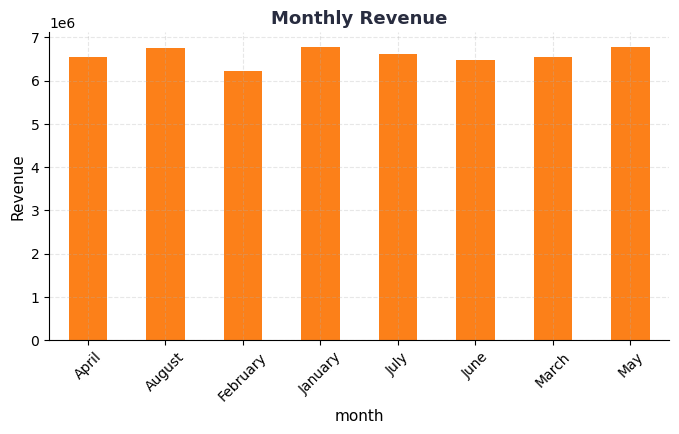

In [88]:
monthly = swiggy_df.groupby("month")["price"].sum()
monthly.plot(kind="bar", color=ORANGE, figsize=(8,4))
plt.title("Monthly Revenue", color=DARK)
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# top restaurants

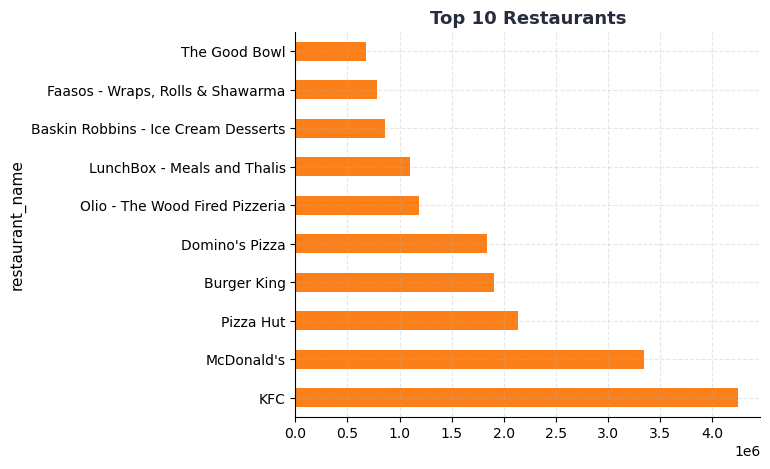

In [89]:
top_rest = swiggy_df.groupby("restaurant_name")["price"].sum().nlargest(10)
top_rest.plot(kind="barh", color=ORANGE, figsize=(6,5))
plt.title("Top 10 Restaurants", color=DARK)
plt.show()

# state analysis

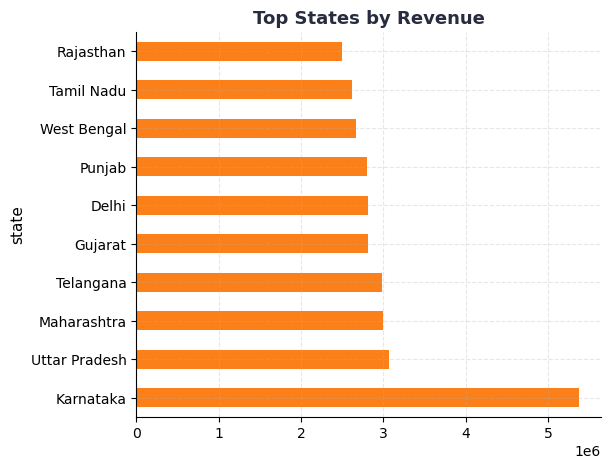

In [90]:
state_rev = swiggy_df.groupby("state")["price"].sum().nlargest(10)
state_rev.plot(kind="barh", color=ORANGE, figsize=(6,5))
plt.title("Top States by Revenue", color=DARK)
plt.show()

# price distribution

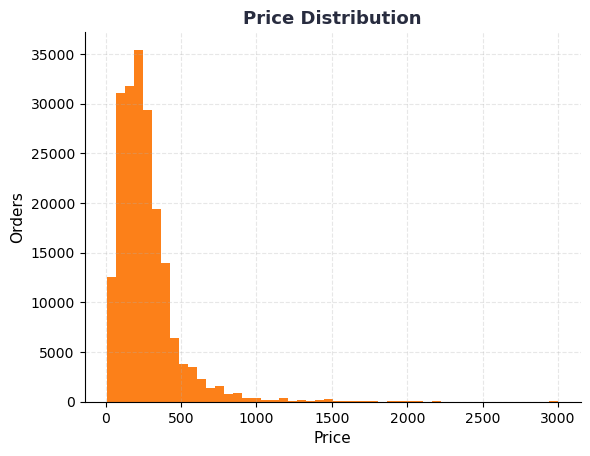

In [91]:
plt.hist(swiggy_df["price"], bins=50, color=ORANGE)
plt.title("Price Distribution", color=DARK)
plt.xlabel("Price")
plt.ylabel("Orders")
plt.show()

# price segementation

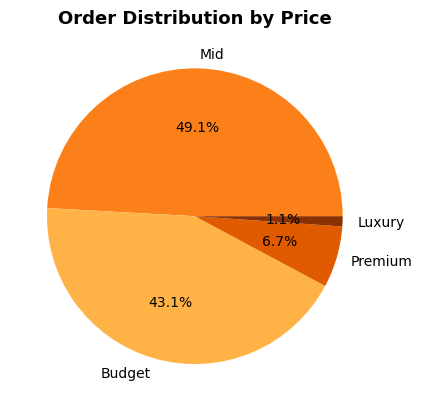

In [92]:
bucket = swiggy_df["price_bucket"].value_counts()
bucket.plot(kind="pie", autopct="%1.1f%%", colors=[ORANGE, "#FFB347", "#E05A00", "#8B3000"])
plt.title("Order Distribution by Price")
plt.ylabel("")
plt.show()

# rating analysis

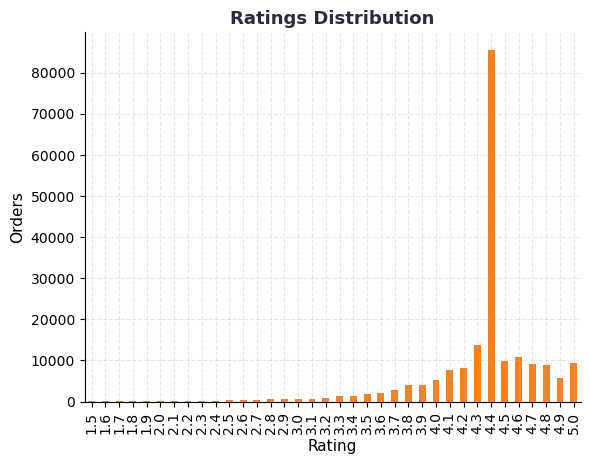

In [93]:
rating_counts = swiggy_df["rating"].value_counts().sort_index()
rating_counts.plot(kind="bar", color=ORANGE)
plt.title("Ratings Distribution", color=DARK)
plt.xlabel("Rating")
plt.ylabel("Orders")
plt.show()

# correlation

In [94]:
corr = swiggy_df[["price","rating"]].corr()
print("Correlation between price and rating:", corr.iloc[0,1])

Correlation between price and rating: 0.02898329370349734


# weekend vs weekday

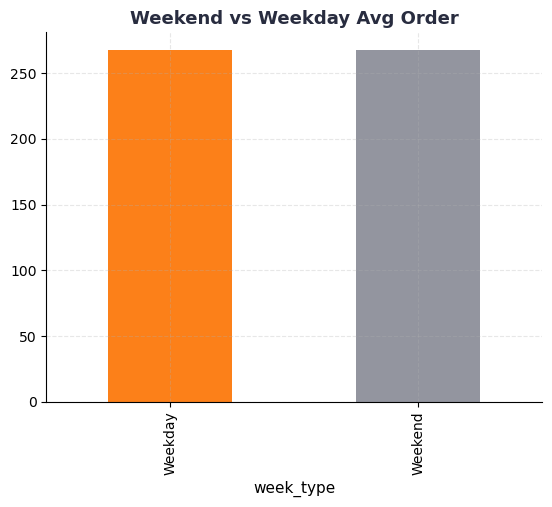

In [95]:
wk = swiggy_df.groupby("week_type")["price"].mean()
wk.plot(kind="bar", color=[ORANGE, GRAY])
plt.title("Weekend vs Weekday Avg Order", color=DARK)
plt.show()

# Summary

# basic metrics

In [96]:
total_rev = swiggy_df["price"].sum()
avg_order = swiggy_df["price"].mean()
total_orders = len(swiggy_df)
print("Total Orders:", total_orders)
print("Total Revenue:", total_rev)
print("Average Order Value:", avg_order)

Total Orders: 197134
Total Revenue: 52721445.730000004
Average Order Value: 267.43963867217224


# counts

In [97]:
num_states = swiggy_df["state"].nunique()
num_cities = swiggy_df["city"].nunique()
num_rest = swiggy_df["restaurant_name"].nunique()
num_dishes = swiggy_df["dish_name"].nunique()
print("States:", num_states)
print("Cities:", num_cities)
print("Restaurants:", num_rest)
print("Dishes:", num_dishes)

States: 28
Cities: 28
Restaurants: 993
Dishes: 55162


# top values

In [98]:
top_state = swiggy_df.groupby("state")["price"].sum().idxmax()
top_rest = swiggy_df.groupby("restaurant_name")["price"].sum().idxmax()
top_month = swiggy_df.groupby("month")["price"].sum().idxmax()
print("Top State:", top_state)
print("Top Restaurant:", top_rest)
print("Top Month:", top_month)

Top State: Karnataka
Top Restaurant: KFC
Top Month: January


# rating %

In [99]:
pct_rated = (swiggy_df["rating_count"] > 0).mean() * 100
print("Orders with rating %:", pct_rated)

Orders with rating %: 59.91457587224933
